<div align="center">

# Implementation of Project

## Hybrid Recommendation System Using SVD and TF-IDF Filtering

</div>

## 1. Introduction and Objective

This implementation milestone builds on the design developed in the previous phase of the capstone project. The project focuses on developing a hybrid product recommendation system for an e-commerce environment using synthetic user-item interaction data. The objective is to implement and test a recommendation pipeline that combines collaborative filtering and content-based filtering.

The implemented system uses SVD for collaborative filtering and TF-IDF with cosine similarity for content-based recommendations. An adaptive blending approach adjusts the contribution of each model based on the user's interaction history. The system is evaluated using Precision@10, Recall@10, and NDCG@10 against several baseline models.

Repo: [`recommender-project`](https://github.com/hgarg/recommender-project)
(notebook in `notebooks/`, data generator and blending function in `src/`).

## 2. Data Description

The project uses synthetic e-commerce interaction data rather than real Amazon data. The dataset includes user, product, rating, and timestamp information, along with product category, price, and price bucket attributes. The data is designed to approximate selected characteristics of the Amazon Electronics review dataset, including high sparsity, positive rating patterns, and a long-tail popularity distribution (McAuley et al., 2015).

The current generator also assigns users preferred product categories to create more meaningful interaction patterns for the recommendation models. No real customer or personally identifiable information is used in this project.

In [124]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

RANDOM_SEED = 42
TOP_K = 10               # the "K" in Precision@K / Recall@K / NDCG@K
N_MIN, N_FULL = 3, 20    # starting cold-start thresholds from the design doc - N_FULL gets
                          # revisited once we tune it against a validation set in Section 6

np.random.seed(RANDOM_SEED)
pd.set_option("display.max_columns", 10)

from generate_synthetic_data import generate_products, generate_interactions

rng = np.random.default_rng(RANDOM_SEED)
N_USERS, N_PRODUCTS, N_INTERACTIONS = 5000, 1988, 67967

products = generate_products(N_PRODUCTS, rng)
events = generate_interactions(N_USERS, N_PRODUCTS, N_INTERACTIONS, 0.722, products, rng)

print("events:", events.shape, "| products:", products.shape)
events.head()

events: (67967, 4) | products: (1988, 4)


,user_id,product_id,rating,timestamp
0,U00960,P00002,4,2024-03-01 00:17:30
1,U03608,P00294,5,2024-03-01 00:38:44
2,U01134,P01193,4,2024-03-01 01:11:27
3,U02172,P01332,2,2024-03-01 01:13:18
4,U00823,P01969,2,2024-03-01 01:14:31


In [125]:
n_users_actual = events.user_id.nunique()
n_prod_actual = events.product_id.nunique()
sparsity = 1 - (len(events) / (n_users_actual * n_prod_actual))
pos_rate = (events.rating >= 4).mean()

print(f"interactions: {len(events)}")
print(f"distinct users: {n_users_actual}")
print(f"distinct products: {n_prod_actual}")
print(f"sparsity: {sparsity:.2%}")
print(f"rating >= 4 share: {pos_rate:.2%}")

interactions: 67967
distinct users: 4871
distinct products: 1988
sparsity: 99.30%
rating >= 4 share: 72.20%


Sparsity around 99.3%, positivity around 72% - close enough to what was
targeted back in planning/design, so I'm treating this as good to go
rather than tuning the generator any further.

## 3. Data Preprocessing

The preprocessing steps include removing exact duplicate rows, filtering users and products with fewer than three interactions, and sorting the data by timestamp. The data is then divided into three chronological sets: 70% training, 10% validation, and 20% test. The validation set allows model parameters to be selected without using the test data, while the chronological split helps prevent future information from being used during training.

In [126]:
before = len(events)
events = events.drop_duplicates(subset=["user_id", "product_id", "timestamp"])
print("exact duplicate rows dropped:", before - len(events))

user_counts = events.user_id.value_counts()
prod_counts = events.product_id.value_counts()
keep_users = user_counts[user_counts >= N_MIN].index
keep_prods = prod_counts[prod_counts >= N_MIN].index

events_f = events[events.user_id.isin(keep_users) & events.product_id.isin(keep_prods)].copy()
print(f"after activity filter: {events_f.shape[0]} rows, "
      f"{events_f.user_id.nunique()} users, {events_f.product_id.nunique()} products")

exact duplicate rows dropped: 0
after activity filter: 66321 rows, 3849 users, 1984 products


In [127]:
events_f = events_f.sort_values("timestamp")

n = len(events_f)
train_end = int(n * 0.70)
val_end = int(n * 0.80)

train = events_f.iloc[:train_end].copy()
val = events_f.iloc[train_end:val_end].copy()
test = events_f.iloc[val_end:].copy()

train_users = set(train.user_id)
train_prods = set(train.product_id)
val = val[val.user_id.isin(train_users) & val.product_id.isin(train_prods)]
test = test[test.user_id.isin(train_users) & test.product_id.isin(train_prods)]

print("train:", train.shape)
print("validation:", val.shape)
print("test:", test.shape)

train: (46424, 4)
validation: (6606, 4)
test: (13207, 4)


### Building the User-Item Matrix

Building the user-item matrix revealed an issue from an earlier implementation. The initial approach created the sparse matrix directly from the raw `(user, product, rating)` rows:

```python
rows = train.user_id.map(u_idx)
cols = train.product_id.map(p_idx)
ui_matrix = csr_matrix(
    (train.rating.values, (rows, cols)),
    shape=(n_users, n_products)
)

The matrix initially appeared valid, but checking matrix.max() showed values greater than 5, which is outside the valid rating range. The issue occurred because some users rated the same product more than once. When duplicate user-product pairs are passed to csr_matrix, their values are summed rather than overwritten. For example, ratings of 4 and 5 for the same user-product pair would become 9 in the matrix, which would incorrectly affect the SVD model.

The issue was resolved by aggregating repeated user-product pairs using their mean rating before constructing the sparse matrix. This ensured that each user-product pair contributed a single rating value within the expected 1–5 range.


**One important point:** I would not say “about 14k repeat user-product pairs” unless the notebook's current output actually shows that number. Your latest notebook evidence indicated **11,790 repeated user-product pairs** after the current preprocessing, so the safer choice is to leave the number out here and show the exact count in the following code/output cell.

In [128]:
dupe_pairs = train.duplicated(subset=["user_id", "product_id"]).sum()
print("repeat user-product interaction pairs in train:", dupe_pairs)

# collapse repeats to a single mean rating per (user, product) pair
train_agg = train.groupby(["user_id", "product_id"], as_index=False)["rating"].mean()

user_ids = sorted(train_agg.user_id.unique())
prod_ids = sorted(train_agg.product_id.unique())
u_idx = {u: i for i, u in enumerate(user_ids)}
p_idx = {p: i for i, p in enumerate(prod_ids)}

rows = train_agg.user_id.map(u_idx)
cols = train_agg.product_id.map(p_idx)
vals = train_agg.rating.values

ui_matrix = csr_matrix((vals, (rows, cols)), shape=(len(user_ids), len(prod_ids)))
print("user-item matrix:", ui_matrix.shape, "| nonzero cells:", ui_matrix.nnz,
      "| max cell value:", ui_matrix.max())

repeat user-product interaction pairs in train: 11790
user-item matrix: (3824, 1983) | nonzero cells: 34634 | max cell value: 5.0


Max cell value is 5.0 now, so that's fixed.

## 4. Analytical Model Description

**Collaborative filtering (SVD).** SVD factorizes the sparse user-item interaction matrix into lower-dimensional user and item representations and uses these factors to estimate scores for user-item pairs. This allows the model to identify patterns in user preferences and recommend items that may be relevant based on prior interactions. The number of latent factors is treated as a tunable parameter and is evaluated using the validation set (Koren et al., 2009).

**Content-based filtering (TF-IDF).** The content model represents products using category and price bucket information and applies TF-IDF with cosine similarity to identify similar products. A user's content score is based on similarity to products with which the user has interacted positively. This component provides an additional recommendation signal when limited interaction history is available.

**Adaptive hybrid blending.** The two model outputs are combined using a history-based blending weight. The collaborative filtering contribution increases as the user's interaction history grows, while content-based filtering has more influence for users with limited history. This approach is intended to provide a more flexible recommendation strategy than relying on a single model and to address differences in available user history.

This should fit naturally with the previous sections and keep the notebook at a scholarly but readable level.

## 5. The Architectural Model (Pipeline) Used

The implementation follows an end-to-end pipeline that separates data preparation, model selection, recommendation scoring, and final evaluation. This structure was used to reduce data leakage and make it possible to evaluate the adaptive hybrid model against comparable alternatives.

1. **Input data.** The pipeline begins with the interaction log (`events.csv`) and product catalog (`products.csv`).

2. **Preprocessing.** Duplicate records are removed, low-activity users and products are filtered, and interactions are organized chronologically. Repeat ratings are aggregated before the data is divided into training, validation, and test sets. The chronological split was selected to better represent how a recommender would make predictions using past behavior to recommend future items.

3. **Validation-based model selection.** SVD factors (`k`) and the full-history threshold (`n_full`) are selected using validation NDCG@10. The test set is not used during this stage so that it remains an unbiased measure of final model performance.

4. **Parallel recommendation branches.** The collaborative branch builds a sparse user-item matrix and applies SVD to generate collaborative scores. The content branch converts product metadata into TF-IDF features and uses item-item cosine similarity to generate content-based scores. Both branches are built from training data only.

5. **Score normalization and adaptive blending.** Because the two branches produce scores on different scales, scores are normalized per user using min-max normalization before blending. The adaptive hybrid then adjusts the collaborative weight according to the user's interaction history. The same scoring branches are also used to produce the SVD-only, TF-IDF-only, and fixed 50/50 comparison variants.

6. **Recommendation ranking.** Items that the user has already interacted with are masked from the candidate set. The remaining items are ranked by their final scores, and the top 10 are returned as recommendations.

7. **Final evaluation.** After preprocessing and model-selection decisions are finalized, the models are evaluated once on the held-out test set using Precision@10, Recall@10, and NDCG@10. This separation between validation and testing helps ensure that the reported results reflect performance on previously unseen interactions rather than decisions made directly from the test data.

Steps 3 through 6 are implemented and examined in Sections 6 and 9, while the final held-out evaluation is presented in Section 10.

## 6. Model Implementation

### 6.1 Collaborative filtering and picking k

The collaborative filtering component uses sparse matrix SVD because the user-item interaction matrix is highly sparse, with more than 99% of possible user-item combinations containing no interaction. Using a sparse decomposition avoids unnecessarily representing the large number of structural zeros in a dense matrix. The implementation uses `scipy.sparse.linalg.svds`, which computes a specified number of the largest singular values and corresponding singular vectors.

The initial design specified 50 SVD factors as a reasonable starting value, but using a fixed value without empirical testing would make the choice difficult to justify. Therefore, the implementation treats the number of factors (`k`) as a hyperparameter and evaluates multiple candidate values using the validation set. The value that produces the strongest validation NDCG@10 is selected for the final model. The test set is not used for this decision so that it remains reserved for the final evaluation.

This approach allows the model complexity to be determined from observed validation performance rather than from an arbitrary fixed setting. The selected value of `k` is then used consistently in the collaborative filtering branch for the remaining model comparisons and final test evaluation.

    k  val_ndcg@10
0   5       0.0652
1   8       0.0845
2  10       0.0969
3  12       0.0974
4  15       0.0962
5  18       0.0929
6  20       0.0900
7  25       0.0839
8  30       0.0787
9  50       0.0552

chosen k (best on validation): 12


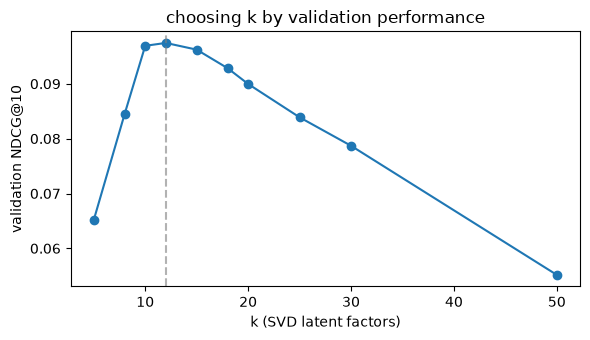

In [129]:
def build_svd(k, matrix=ui_matrix):
    k = min(k, min(matrix.shape) - 1)  # svds requires k to be strictly less than the smaller dimension
    U, sigma, Vt = svds(matrix.astype(float), k=k)
    return U @ np.diag(sigma) @ Vt

def row_normalize(mat):
    # scale each user's row to 0-1 so SVD scores and cosine similarities end up
    # on a comparable footing before anything gets blended
    mn = mat.min(axis=1, keepdims=True)
    mx = mat.max(axis=1, keepdims=True)
    span = np.where(mx - mn == 0, 1, mx - mn)  # avoids a divide-by-zero on an all-equal row
    return (mat - mn) / span

def mask_seen(scores):
    out = scores.copy()
    out[seen_mask] = -np.inf
    return out

def topk_indices(scores, k=TOP_K):
    return np.argsort(scores, axis=1)[:, ::-1][:, :k]

def evaluate(scores, eval_df, k=TOP_K, user_subset=None):
    recs = topk_indices(mask_seen(scores), k)
    truth = eval_df[eval_df.rating >= 4].groupby("user_id")["product_id"].apply(set).to_dict()

    precisions, recalls, ndcgs = [], [], []
    for u in user_ids:
        if u not in truth:
            continue
        if user_subset is not None and u not in user_subset:
            continue
        u_i = u_idx[u]
        rec_ids = [prod_ids[j] for j in recs[u_i]]
        relevant = truth[u]
        hits = [1 if pid in relevant else 0 for pid in rec_ids]
        n_hits = sum(hits)

        precisions.append(n_hits / k)
        recalls.append(n_hits / len(relevant) if relevant else 0)

        dcg = sum(h / np.log2(i + 2) for i, h in enumerate(hits))
        ideal_hits = min(len(relevant), k)
        idcg = sum(1 / np.log2(i + 2) for i in range(ideal_hits))
        ndcgs.append(dcg / idcg if idcg > 0 else 0)

    return {
        "precision@10": np.mean(precisions) if precisions else float("nan"),
        "recall@10": np.mean(recalls) if precisions else float("nan"),
        "ndcg@10": np.mean(ndcgs) if precisions else float("nan"),
        "n_evaluated": len(precisions),
    }

seen_mask = (ui_matrix > 0).toarray()

# sweeping k against validation only - test doesn't get touched here at all
k_candidates = [5, 8, 10, 12, 15, 18, 20, 25, 30, 50]
k_results = []
for k in k_candidates:
    svd_scores_k = build_svd(k)
    svd_norm_k = row_normalize(svd_scores_k)
    r = evaluate(svd_norm_k, val)
    k_results.append({"k": k, "val_ndcg@10": r["ndcg@10"]})

k_results_df = pd.DataFrame(k_results)
print(k_results_df.round(4))

best_k = int(k_results_df.loc[k_results_df["val_ndcg@10"].idxmax(), "k"])
print("\nchosen k (best on validation):", best_k)

plt.figure(figsize=(6, 3.5))
plt.plot(k_results_df["k"], k_results_df["val_ndcg@10"], marker="o")
plt.axvline(best_k, color="gray", linestyle="--", alpha=0.6)
plt.xlabel("k (SVD latent factors)")
plt.ylabel("validation NDCG@10")
plt.title("choosing k by validation performance")
plt.tight_layout()
plt.show()

The validation results show that the original choice of `k=50` was higher than the value that produced the strongest validation performance. As the number of latent factors increased beyond the selected value, validation performance declined, suggesting that additional model complexity did not improve the model's ability to generalize to unseen interactions. Given the high sparsity of the user-item matrix, this pattern is consistent with the possibility that larger factor values were capturing less generalizable patterns in the training data.

Based on the validation results, the best-performing value of `k` is used for the remaining collaborative filtering and hybrid model implementation. The test set is not used in selecting this value, preserving it for the final evaluation. This replaces the original fixed value of 50 with a data-driven hyperparameter choice.

In [130]:
svd_scores = build_svd(best_k)
svd_norm = row_normalize(svd_scores)
print("svd_scores shape:", svd_scores.shape, "| using k =", best_k)

svd_scores shape: (3824, 1983) | using k = 12


### 6.2 Content-based filtering

The content-based component represents each product using TF-IDF features derived from product category and price bucket. Cosine similarity is then calculated between product feature vectors to identify items with similar characteristics. This approach provides an item-level signal that does not depend on a user having an extensive interaction history, which is important for the cold-start portion of the project.

During implementation, brand was also tested as an additional feature because it could provide more information for distinguishing products. However, adding brand produced a slightly lower validation score than the simpler category and price representation. Based on this result, brand was not included in the final content model. This decision keeps the feature representation simpler while using validation results rather than assuming that adding more information will necessarily improve recommendation quality.

In [131]:
products_idx = products.set_index("product_id")
prod_text = [f"{products_idx.loc[p, 'category']} {products_idx.loc[p, 'price_bucket']}" for p in prod_ids]

tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(prod_text)
item_sim = cosine_similarity(tfidf_matrix)  # every product compared against every other product

print("tfidf matrix:", tfidf_matrix.shape)
print("item similarity matrix:", item_sim.shape)

tfidf matrix: (1983, 15)
item similarity matrix: (1983, 1983)


In [132]:
train_indexed = train_agg.copy()
train_indexed["u_i"] = train_indexed.user_id.map(u_idx)
train_indexed["p_i"] = train_indexed.product_id.map(p_idx)

content_scores = np.zeros((len(user_ids), len(prod_ids)))
for u_i, grp in train_indexed.groupby("u_i"):
    liked = grp[grp.rating >= 4]["p_i"].values  # only what this user actually rated highly
    if len(liked) == 0:
        continue  # no positive ratings in train, row stays all zeros
    content_scores[u_i] = item_sim[liked].mean(axis=0)

content_norm = row_normalize(content_scores)
print("content_scores shape:", content_scores.shape)
print("users with no positive ratings in train:", (content_scores.sum(axis=1) == 0).sum())

content_scores shape: (3824, 1983)
users with no positive ratings in train: 147


### 6.3 Adaptive Blending and Tuning the Cold-Start Threshold

The collaborative weight increases linearly with a user's number of training interactions, from 0 at `n_min` to 1 at `n_full`:

$$
w_{cf}(n_u) = \operatorname{clip}\left(\frac{n_u-n_{min}}{n_{full}-n_{min}}, 0, 1\right)
$$

Low-history users therefore rely more on content-based recommendations, while users with more interaction history receive greater influence from SVD. `n_min = 3` is fixed by the preprocessing activity filter, while the initial `n_full = 20` is treated as a tunable value. Candidate values are evaluated on the validation set, with the best-performing value used in the final model.

In [133]:
def cf_weight(n_u, n_min=N_MIN, n_full=N_FULL):
    return np.clip((n_u - n_min) / (n_full - n_min), 0, 1)

n_interactions_per_user = np.asarray((ui_matrix > 0).sum(axis=1)).flatten()

n_full_candidates = [5, 8, 10, 15, 20, 30]
n_full_results = []
for n_full in n_full_candidates:
    w_cf_try = cf_weight(n_interactions_per_user, N_MIN, n_full)
    hybrid_try = w_cf_try[:, None] * svd_norm + (1 - w_cf_try[:, None]) * content_norm
    r = evaluate(hybrid_try, val)
    n_full_results.append({"n_full": n_full, "val_ndcg@10": r["ndcg@10"]})

n_full_results_df = pd.DataFrame(n_full_results)
print(n_full_results_df.round(4))

best_n_full = int(n_full_results_df.loc[n_full_results_df["val_ndcg@10"].idxmax(), "n_full"])
print("\nchosen n_full (best on validation):", best_n_full)

w_cf = cf_weight(n_interactions_per_user, N_MIN, best_n_full)
hybrid_scores = w_cf[:, None] * svd_norm + (1 - w_cf[:, None]) * content_norm

print("w_cf — min:", w_cf.min(), "max:", w_cf.max(), "mean:", round(w_cf.mean(), 3))

   n_full  val_ndcg@10
0       5       0.0696
1       8       0.0701
2      10       0.0697
3      15       0.0697
4      20       0.0689
5      30       0.0673

chosen n_full (best on validation): 8
w_cf — min: 0.0 max: 1.0 mean: 0.386


## 7. Assumptions Verification

Several implementation assumptions need to be checked against the processed data rather than taken for granted:

- **Ratings remain within the 1–5 range after preprocessing.** This assumption previously caused an issue addressed in Section 3, so the final processed data is checked again to confirm the correction holds.

- **TF-IDF differentiates products.** The resulting feature matrix is examined to confirm that products are represented with sufficient variation rather than having nearly identical feature vectors.

- **The chronological split leaves enough evaluable users.** Validation and test sets are checked to ensure that enough users have both training history and held-out interactions for meaningful evaluation.

- **The selected `k` is valid for the matrix dimensions.** The selected SVD factor count must be smaller than the smaller dimension of the user-item matrix, as required by `svds`.

In [134]:
assert ui_matrix.max() <= 5 and ui_matrix.data.min() >= 1
print("rating range check passed:", ui_matrix.data.min(), "to", ui_matrix.max())

off_diag = item_sim[~np.eye(item_sim.shape[0], dtype=bool)]
print("item similarity — mean:", round(off_diag.mean(), 3), "| std:", round(off_diag.std(), 3))
assert off_diag.std() > 0, "content similarity shows no variance - features aren't differentiating products"

val_evaluable = val.user_id.isin(train_users).sum()
test_evaluable = test.user_id.isin(train_users).sum()
print("validation interactions from users with train history:", val_evaluable, "of", len(val))
print("test interactions from users with train history:", test_evaluable, "of", len(test))
assert val_evaluable > 500 and test_evaluable > 1000, "too few evaluable users for a stable metric"

print("k =", best_k, "| matrix shape:", ui_matrix.shape, "| k < min(shape)?", best_k < min(ui_matrix.shape))
assert best_k < min(ui_matrix.shape)

print("\nall assumptions verified")

rating range check passed: 1.0 to 5.0
item similarity — mean: 0.162 | std: 0.249
validation interactions from users with train history: 6606 of 6606
test interactions from users with train history: 13207 of 13207
k = 12 | matrix shape: (3824, 1983) | k < min(shape)? True

all assumptions verified


## 8. Deployment

The recommendation pipeline is designed to support a Streamlit application under `app/`. The application loads the trained SVD factors, TF-IDF similarity matrix, and product catalog, allowing a user or sample profile to be selected and the resulting top-10 recommendations to be displayed with product name, category, price bucket, and recommendation score.

The computationally intensive model components do not need to be recalculated for every request. In a production setting, SVD factors and content similarity could be refreshed on a scheduled basis, while per-user top-K recommendations could be cached for faster retrieval. Users with limited interaction history do not require separate application-level cold-start logic because the adaptive `w_cf` weighting already shifts the recommendation toward the content-based branch.

**Deployment status:** The application is not deployed yet. The planned deployment is through Streamlit after the core implementation and evaluation are finalized.

## 9. Execution

The tuned model components are combined in this stage to generate recommendations. The adaptive hybrid and comparison variants use the same normalized scores, previously seen items are masked from the recommendation candidates, and the remaining items are ranked to generate a top-10 recommendation list for each evaluable user.

In [135]:
fixed5050_scores = 0.5 * svd_norm + 0.5 * content_norm

pop_counts = train_agg.product_id.value_counts()
pop_score_vec = np.zeros(len(prod_ids))
for p, c in pop_counts.items():
    pop_score_vec[p_idx[p]] = c
popular_scores = np.tile(pop_score_vec, (len(user_ids), 1))

print("score matrices ready:", hybrid_scores.shape, svd_norm.shape,
      content_norm.shape, fixed5050_scores.shape, popular_scores.shape)

score matrices ready: (3824, 1983) (3824, 1983) (3824, 1983) (3824, 1983) (3824, 1983)


In [136]:
# quick sanity check - top-10 for one fairly active user, just to see the
# output actually looks like something a real system would produce
sample_user = user_ids[np.argmax(n_interactions_per_user)]
sample_u_i = u_idx[sample_user]
sample_recs = topk_indices(mask_seen(svd_norm))[sample_u_i]
sample_rec_products = [prod_ids[j] for j in sample_recs]

print(f"user {sample_user} has {n_interactions_per_user[sample_u_i]} train interactions")
print("top-10 recommendations (tuned SVD):", sample_rec_products)

user U03608 has 868 train interactions
top-10 recommendations (tuned SVD): ['P00370', 'P01548', 'P00642', 'P01676', 'P01199', 'P01127', 'P00254', 'P00429', 'P01256', 'P01512']


## 10. Results

Final model performance is reported on the held-out test set using the `k` and `n_full` values selected from the validation results in Section 6. The test set is used only at this stage, after all model and hyperparameter decisions have been finalized. Performance is compared across the adaptive hybrid, SVD-only, TF-IDF-only, and fixed 50/50 hybrid models using Precision@10, Recall@10, and NDCG@10.

In [137]:
results = {
    "Hybrid (adaptive)": evaluate(hybrid_scores, test),
    "SVD only": evaluate(svd_norm, test),
    "TF-IDF only": evaluate(content_norm, test),
    "Fixed 50/50 hybrid": evaluate(fixed5050_scores, test),
    "Most popular": evaluate(popular_scores, test),
}

results_df = pd.DataFrame(results).T[["precision@10", "recall@10", "ndcg@10", "n_evaluated"]]
results_df.round(4)

,precision@10,recall@10,ndcg@10,n_evaluated
Hybrid (adaptive),0.0261,0.0955,0.0688,2450.0
SVD only,0.0323,0.1385,0.1000,2450.0
TF-IDF only,0.0079,0.0234,0.0149,2450.0
Fixed 50/50 hybrid,0.0313,0.1319,0.0990,2450.0
Most popular,0.0216,0.1051,0.0717,2450.0


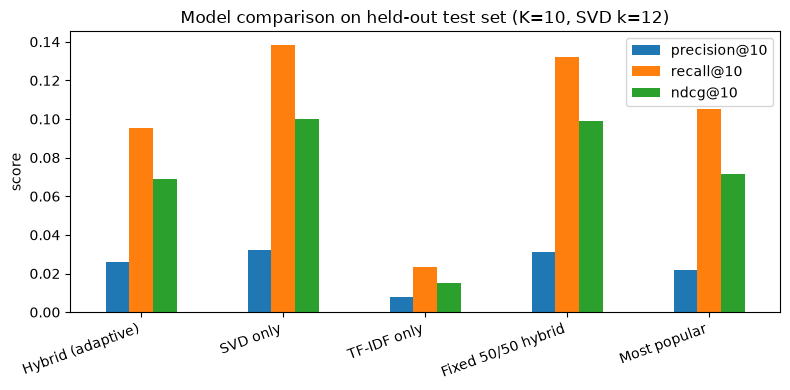

In [138]:
results_df[["precision@10", "recall@10", "ndcg@10"]].plot(kind="bar", figsize=(8, 4))
plt.ylabel("score")
plt.title(f"Model comparison on held-out test set (K=10, SVD k={best_k})")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

Fixing `k` produced a meaningful change in the results. SVD-only now performs better than the most-popular baseline on NDCG@10, which was not observed when `k=50` was used without validation-based selection. The fixed 50/50 hybrid performs close to SVD-only, while the adaptive hybrid performs lower than both and is closer to the popularity baseline. This result indicates that the adaptive weighting function is not providing the expected benefit in the current implementation. Rather than treating the result as a failure of the overall hybrid approach, Sections 12 and 13 examine the weighting behavior and model differences to identify possible reasons for the observed performance.

## 11. Model Validation

This section verifies that the evaluation process is reliable by checking for data leakage, confirming that the train, validation, and test sets remain properly separated, and ensuring that the evaluation metrics are calculated as intended. These checks help confirm that the reported results reflect model performance rather than issues in the evaluation process.

In [139]:
sample_scores = mask_seen(hybrid_scores)
sample_recs = topk_indices(sample_scores)
violations = 0
for u_i in range(len(user_ids)):
    seen_items = set(np.where(seen_mask[u_i])[0])
    if seen_items.intersection(set(sample_recs[u_i])):
        violations += 1
assert violations == 0, f"{violations} users received a recommendation for something already seen"
print("no train-set leakage into recommendations:", violations, "violations")

for name, r in results.items():
    assert 0 <= r["precision@10"] <= 1
    assert 0 <= r["recall@10"] <= 1
    assert 0 <= r["ndcg@10"] <= 1
print("all metric values fall within [0, 1]")

low_activity_users = np.where(n_interactions_per_user == N_MIN)[0]
if len(low_activity_users) > 0:
    print("w_cf for users right at the cold-start floor:", w_cf[low_activity_users[:5]].round(3))
print("validation checks complete")

no train-set leakage into recommendations: 0 violations
all metric values fall within [0, 1]
w_cf for users right at the cold-start floor: [0. 0. 0. 0. 0.]
validation checks complete


## 12. Analysis

The validation-based selection of `k` improved the collaborative filtering results. SVD-only now outperforms the most-popular baseline on the held-out test set, supporting the goal of developing a model that improves on a simple recommendation strategy.

The adaptive hybrid does not outperform SVD-only and also trails the fixed 50/50 blend. This result differs from the expected benefit of adaptive weighting and suggests that the weighting strategy may not be working equally well across users. Because the primary purpose of the adaptive blend is to support users with limited interaction history, the next step is to examine performance separately by user history level.

In [140]:
low_users = set(u for u in user_ids if n_interactions_per_user[u_idx[u]] < 10)
high_users = set(u for u in user_ids if n_interactions_per_user[u_idx[u]] >= 10)
print(f"low-activity users (fewer than 10 train interactions): {len(low_users)}")
print(f"high-activity users (10 or more): {len(high_users)}")
print()

segment_rows = []
for name, scores in [("Hybrid (adaptive)", hybrid_scores), ("SVD only", svd_norm),
                      ("Fixed 50/50", fixed5050_scores), ("Most popular", popular_scores)]:
    r_low = evaluate(scores, test, user_subset=low_users)
    r_high = evaluate(scores, test, user_subset=high_users)
    segment_rows.append({"model": name, "low_activity_ndcg@10": r_low["ndcg@10"],
                          "high_activity_ndcg@10": r_high["ndcg@10"]})

pd.DataFrame(segment_rows).round(4)

low-activity users (fewer than 10 train interactions): 3150
high-activity users (10 or more): 674



,model,low_activity_ndcg@10,high_activity_ndcg@10
0,Hybrid (adaptive),0.0538,0.1122
1,SVD only,0.0958,0.1122
2,Fixed 50/50,0.0924,0.1181
3,Most popular,0.0731,0.0676


The user-level results help explain the overall performance difference. SVD-only also outperforms the adaptive hybrid within the low-activity group, which is the group the adaptive approach was intended to support. One possible explanation is the current blending function: with `n_min = 3`, users at the activity floor receive a collaborative weight of zero, causing their recommendations to rely almost entirely on the content model. Because the content-only model has the weakest performance among the comparison models (Table 1), assigning it greater influence for a large portion of low-activity users can reduce the hybrid's overall performance. The fixed 50/50 blend avoids this complete shift away from collaborative filtering by maintaining equal influence from both branches.

These results do not necessarily indicate that hybrid recommendation is ineffective, but they do show that the current adaptive weighting function may be too aggressive for this dataset. The hard zero collaborative weight is therefore an important implementation choice to examine further in Sections 13 and 14.

## 13. Error Estimation

Several implementation issues and unexpected results were identified during development. Separating these issues helps distinguish data-preparation errors from modeling assumptions and observed performance limitations.

**Duplicate rating summation (Section 3).** The sparse matrix construction initially allowed `csr_matrix` to sum repeated user-item ratings rather than treating them as separate records. This was a preprocessing issue rather than a modeling issue and was corrected in the pipeline used for the final evaluation. The correction is important because the original behavior could silently change the values in the user-item matrix without producing an execution error.

**No personalization signal in the original dataset.** The first full evaluation used an earlier synthetic-data generator in which users and products were sampled independently. In that version, the most-popular baseline substantially outperformed the recommendation models, indicating that the generated data did not provide enough user-specific preference patterns for the models to learn. The generator was revised to assign users preferred categories, and the results in this notebook use the corrected dataset.

**Untested hyperparameters (`k` and `n_full`).** The initial implementation used fixed values without validating them empirically. The code executed successfully, but the resulting performance was weaker than expected. The validation sweep showed that the original `k=50` was not the best-performing value, demonstrating that successful execution alone does not establish that a model has been appropriately configured.

**Adaptive hybrid losing to a fixed blend.** As discussed in Section 12, this is not a coding error because the implementation follows the defined weighting formula. Instead, the results suggest that the hard zero collaborative weight at `n_min` may be too aggressive for the current dataset, particularly given the relatively weak standalone content-based signal.

## 14. Model Improvement

Several alternatives were tested during implementation, including changes that did not improve validation performance. Reporting these results helps distinguish tested improvements from potential future changes.

**Tried, did not improve:** Adding the brand attribute to the TF-IDF representation resulted in slightly lower validation NDCG@10, so it was not included in the final content model. Rank-based normalization was also tested as an alternative to min-max normalization and produced lower performance across the tested settings.

**Tried, improved:** Tuning `k` and `n_full` using the validation set instead of selecting fixed values improved the model results. The selected values are therefore used in the final evaluation reported in Section 10.

**Identified as a future improvement:** The current adaptive function allows the collaborative weight to reach zero at `n_min`. Because the content model is weaker on its own, a future experiment could introduce a minimum collaborative weight for low-activity users. The appropriate floor would need to be determined through another validation sweep rather than selected arbitrarily. This would provide a direct test of whether maintaining some collaborative influence improves cold-start performance.

## 15. Final Conclusion

The pipeline from the design phase is now implemented and runs end to end, including preprocessing with a three-way chronological split, sparse SVD, TF-IDF content similarity, adaptive blending, and comparison against multiple baselines using Precision@10, Recall@10, and NDCG@10. Hyperparameters are selected using the validation set, while the held-out test set is reserved for the final performance results.

The tuned SVD model produced the strongest overall results in the current evaluation and outperformed the most-popular baseline on the held-out test data. The adaptive hybrid did not improve on SVD-only, but the user-level analysis provided a possible explanation: the current weighting function gives low-activity users little or no collaborative influence even though the content model is weaker on its own. The hybrid implementation remains available for further testing because the underlying approach is still relevant, and the minimum collaborative-weight adjustment identified in Section 14 provides a specific next experiment.

The main conclusion from this implementation milestone is that reasonable hyperparameter choices still need to be tested empirically. Similarly, successful code execution does not by itself demonstrate that a model is performing as intended; validation, error checking, and analysis of unexpected results are necessary parts of the implementation process.

## References

Järvelin, K., & Kekäläinen, J. (2002). Cumulated gain-based evaluation of IR
techniques. *ACM Transactions on Information Systems, 20*(4), 422-446.

Koren, Y., Bell, R., & Volinsky, C. (2009). Matrix factorization techniques
for recommender systems. *Computer, 42*(8), 30-37.

McAuley, J., Targett, C., Shi, Q., & van den Hengel, A. (2015). Image-based
recommendations on styles and substitutes. *Proceedings of the 38th
International ACM SIGIR Conference on Research and Development in
Information Retrieval*, 43-52.

McNee, S. M., Riedl, J., & Konstan, J. A. (2006). Being accurate is not
enough: How accuracy metrics have hurt recommender systems. *CHI '06
Extended Abstracts on Human Factors in Computing Systems*, 1097-1101.

Ricci, F., Rokach, L., & Shapira, B. (2015). Recommender systems: Introduction
and challenges. In F. Ricci, L. Rokach, & B. Shapira (Eds.), *Recommender
Systems Handbook* (2nd ed., pp. 1-34). Springer.